# Does it rain more in Seattle, WA, than in Syracuse, NY?

## Introduction 
This analysis shows whether Seattle, WA gets more precipitation (in inches) than Syracuse, NY. Seattle is known for its rainy weather, but this analysis uses precipitation data from both cities to measure and compare quantitatively. 

## Importing Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
seattle = pd.read_csv("../data/seattle_rain.csv")
syracuse = pd.read_csv("../data/Syracuse.csv")

## Inspecting the Data

In [4]:
seattle.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,WESD,WESF
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/1/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/2/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/3/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/4/18,NaN,NaN,0.00,NaN,NaN,NaN,NaN
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",1/5/18,NaN,NaN,0.25,NaN,NaN,NaN,NaN


In [5]:
syracuse.head()

,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD
0,USW00014771,"SYRACUSE HANCOCK INTERNATIONAL AIRPORT, NY US",2018-01-01,NaN,NaN,0.06,2.8,7.1
1,USW00014771,"SYRACUSE HANCOCK INTERNATIONAL AIRPORT, NY US",2018-01-02,NaN,NaN,0.02,1.3,9.1
2,USW00014771,"SYRACUSE HANCOCK INTERNATIONAL AIRPORT, NY US",2018-01-03,NaN,NaN,0.00,0.0,9.1
3,USW00014771,"SYRACUSE HANCOCK INTERNATIONAL AIRPORT, NY US",2018-01-04,NaN,NaN,0.09,6.7,7.9
4,USW00014771,"SYRACUSE HANCOCK INTERNATIONAL AIRPORT, NY US",2018-01-05,NaN,NaN,0.08,7.9,15.0


In [6]:
seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   str    
 1   NAME     1658 non-null   str    
 2   DATE     1658 non-null   str    
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), str(3)
memory usage: 194.4 KB


In [7]:
syracuse.info()

<class 'pandas.DataFrame'>
RangeIndex: 16653 entries, 0 to 16652
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  16653 non-null  str    
 1   NAME     16653 non-null  str    
 2   DATE     16653 non-null  str    
 3   DAPR     269 non-null    float64
 4   MDPR     269 non-null    float64
 5   PRCP     15401 non-null  float64
 6   SNOW     12375 non-null  float64
 7   SNWD     7604 non-null   float64
dtypes: float64(5), str(3)
memory usage: 1.7 MB


### Converting Dates

In [9]:
seattle["DATE"] = pd.to_datetime(seattle["DATE"])
syracuse["DATE"] = pd.to_datetime(syracuse["DATE"])

/var/folders/gh/p5knw9fn5ngbjb1cr08t7bwc0000gn/T/ipykernel_22628/2794237813.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  seattle["DATE"] = pd.to_datetime(seattle["DATE"])


In [10]:
seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   STATION  1658 non-null   str           
 1   NAME     1658 non-null   str           
 2   DATE     1658 non-null   datetime64[us]
 3   DAPR     23 non-null     float64       
 4   MDPR     23 non-null     float64       
 5   PRCP     1636 non-null   float64       
 6   SNOW     353 non-null    float64       
 7   SNWD     66 non-null     float64       
 8   WESD     15 non-null     float64       
 9   WESF     28 non-null     float64       
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 183.1 KB


In [12]:
syracuse["STATION"].nunique()

21

In [14]:
syracuse["STATION"].value_counts()

STATION
USW00014771    1826
US1NYOG0010    1794
US1NYOG0046    1768
US1NYOG0052    1732
US1NYOG0012    1709
USC00300870    1595
US1NYOG0028    1234
US1NYOG0071    1169
USC00300379     909
US1NYOG0002     893
US1NYOG0076     506
US1NYOG0072     298
US1NYOG0067     268
US1NYOG0006     245
US1NYOG0066     232
US1NYOG0075     135
US1NYOG0068     112
US1NYOG0031      99
US1NYOG0080      89
US1NYOG0079      34
US1NYOG0062       6
Name: count, dtype: int64

### Selecting a Syracuse Weather Station 

The Syracuse dataset has multiple locations of the weather station. In order to compare and contrast with the Seattle dataset, I will choose one consistent station (Hancock Intl. Airport, USW00014771) rather than multiple.  

In [18]:
syracuse = syracuse[syracuse["STATION"] == "USW00014771"].copy()

In [19]:
syracuse.shape

(1826, 8)

### Narrowing Date Range

The Seattle dataset's date ends before the end of 2022, so in order to make the comparison fair and uniformed, I will use the date range of January 1, 2018 to September 9, 2022 for both datasets. 

In [20]:
start_date = "2018-01-01"
end_date = "2022-09-09"

seattle = seattle[
    (seattle["DATE"] >= start_date) &
    (seattle["DATE"] <= end_date) 
    ].copy()

syracuse = syracuse[
    (syracuse["DATE"] >= start_date) &
    (syracuse["DATE"] <= end_date)
    ].copy()

### Checking for Missing Value 

In the dataset, there are some precipitation data that are missing. This does not necessarily mean that there was 0 drops of rain, so we won't automatically be treating the missing values as a zero. 

In [22]:
seattle["PRCP"].isna().sum()

np.int64(22)

In [23]:
syracuse["PRCP"].isna().sum()

np.int64(0)

In [24]:
seattle = seattle.dropna(subset=["PRCP"]).copy()
syracuse = syracuse.dropna(subset=["PRCP"]).copy()

In [25]:
seattle["PRCP"].isna().sum()

np.int64(0)

In [26]:
syracuse["PRCP"].isna().sum()

np.int64(0)

### Selecting Relevant Variables

Since this analysis only focuses on the date and the amount of precipitation, we don't need the excess data. Only looking at those two variables will be make it easier for us to understand. 

In [28]:
seattle = seattle[["DATE", "PRCP"]].copy()
syracuse = syracuse[["DATE", "PRCP"]].copy()

In [32]:
seattle = seattle.rename(columns={
    "DATE": "date",
    "PRCP": "precipitation"
})

syracuse = syracuse.rename(columns={
    "DATE": "date",
    "PRCP": "precipitation"
})

In [33]:
seattle["city"] = "Seattle"
syracuse["city"] = "Syracuse"

In [34]:
seattle.head()

,date,precipitation,city
0,2018-01-01,0.00,Seattle
1,2018-01-02,0.00,Seattle
2,2018-01-03,0.00,Seattle
3,2018-01-04,0.00,Seattle
4,2018-01-05,0.25,Seattle


In [35]:
syracuse.head()

,date,precipitation,city
0,2018-01-01,0.06,Syracuse
1,2018-01-02,0.02,Syracuse
2,2018-01-03,0.00,Syracuse
3,2018-01-04,0.09,Syracuse
4,2018-01-05,0.08,Syracuse


### Combining Datasets

I will be combining two data sets into one, so we can see one row with different dates, precipitation data, and specific city for each date. 

In [37]:
weather = pd.concat([seattle, syracuse], ignore_index=True)

In [38]:
weather.head()

,date,precipitation,city
0,2018-01-01,0.00,Seattle
1,2018-01-02,0.00,Seattle
2,2018-01-03,0.00,Seattle
3,2018-01-04,0.00,Seattle
4,2018-01-05,0.25,Seattle


In [39]:
weather.tail()

,date,precipitation,city
3231,2022-09-05,0.28,Syracuse
3232,2022-09-06,0.03,Syracuse
3233,2022-09-07,0.30,Syracuse
3234,2022-09-08,0.01,Syracuse
3235,2022-09-09,0.00,Syracuse


In [40]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 3236 entries, 0 to 3235
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3236 non-null   datetime64[us]
 1   precipitation  3236 non-null   float64       
 2   city           3236 non-null   str           
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 100.2 KB


In [41]:
weather["city"].value_counts()

city
Syracuse    1713
Seattle     1523
Name: count, dtype: int64

### Creating Derived Variables

To support analysis over time, I will create year and month variables from the date column. These variables will let us summarize the precipitation to be summarized by year and month. 

In [46]:
weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month

In [47]:
weather.head()

,date,precipitation,city,year,month
0,2018-01-01,0.00,Seattle,2018,1
1,2018-01-02,0.00,Seattle,2018,1
2,2018-01-03,0.00,Seattle,2018,1
3,2018-01-04,0.00,Seattle,2018,1
4,2018-01-05,0.25,Seattle,2018,1


### Summary Statistics

This is a summary statistics for each precipitation in each city. This will provide an initial comparison of recorded precipitation in both Seattle and Syracuse 

In [48]:
weather.groupby("city")["precipitation"].agg(
    ["count", "mean", "median", "std", "sum", "min", "max"]
)

,count,mean,median,std,sum,min,max
city,,,,,,,
Seattle,1523,0.108746,0.01,0.245455,165.62,0.0,2.60
Syracuse,1713,0.115791,0.00,0.258503,198.35,0.0,2.72


### Total Precipitation by City

The purpose of this section is to directly compare the amount of precipitation each city receives. 

In [49]:
total_precipitation = (
    weather.groupby("city", as_index=False)["precipitation"]
    .sum()
)
total_precipitation

,city,precipitation
0,Seattle,165.62
1,Syracuse,198.35


### Visualization

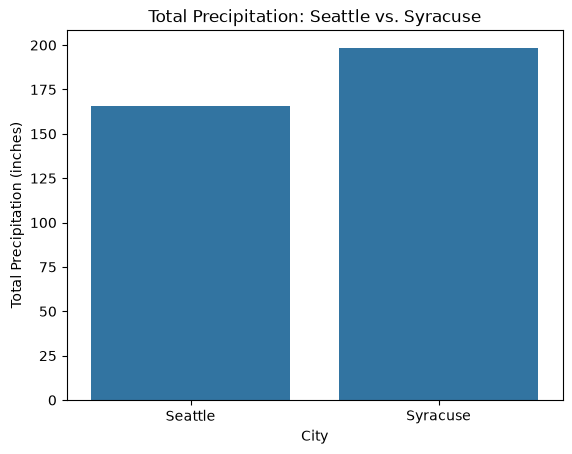

In [51]:
sb.barplot(
    data=total_precipitation,
    x="city",
    y="precipitation"
)
plt.title("Total Precipitation: Seattle vs. Syracuse")
plt.xlabel("City")
plt.ylabel("Total Precipitation (inches)")
plt.show()

Result: The bar graph shows that Syracuse recevied more precipitation than Seattle during 2018-2022. 

In [52]:
weather.to_csv("../data/weather_clean.csv", index=False)

In [53]:
weather_clean = pd.read_csv("../data/weather_clean.csv")
weather_clean.head()

,date,precipitation,city,year,month
0,2018-01-01,0.00,Seattle,2018,1
1,2018-01-02,0.00,Seattle,2018,1
2,2018-01-03,0.00,Seattle,2018,1
3,2018-01-04,0.00,Seattle,2018,1
4,2018-01-05,0.25,Seattle,2018,1
